In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 636.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
zip_path = '/content/drive/MyDrive/signature_detection_dataset/signature_snn.zip'
extract_path = '/content/signature_snn'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [ ]:
import os
for root, dirs, files in os.walk("/content/signature_snn"):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", len(files))
    print("-"*50)

/content/signature_snn
Folders: ['BHSig260-Bengali', 'CEDAR', 'BHSig260-Hindi']
Files: 0
--------------------------------------------------
/content/signature_snn/BHSig260-Bengali
Folders: ['BHSig260-Bengali']
Files: 0
--------------------------------------------------
/content/signature_snn/BHSig260-Bengali/BHSig260-Bengali
Folders: ['57', '8', '21', '26', '81']
Files: 0
--------------------------------------------------
/content/signature_snn/BHSig260-Bengali/BHSig260-Bengali/57
Folders: []
Files: 54
--------------------------------------------------
/content/signature_snn/BHSig260-Bengali/BHSig260-Bengali/8
Folders: []
Files: 54
--------------------------------------------------
/content/signature_snn/BHSig260-Bengali/BHSig260-Bengali/21
Folders: []
Files: 54
--------------------------------------------------
/content/signature_snn/BHSig260-Bengali/BHSig260-Bengali/26
Folders: []
Files: 54
--------------------------------------------------
/content/signature_snn/BHSig260-Bengali/BHS

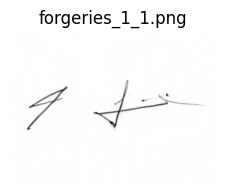

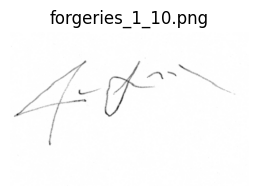

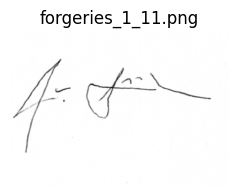

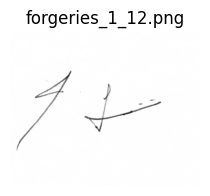

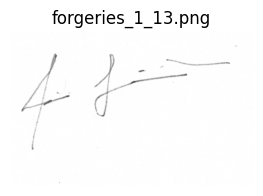

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
person_folder = "/content/signature_snn/CEDAR/CEDAR/1"
images = sorted(os.listdir(person_folder))[:5]
for img_name in images:
    img = cv2.imread(os.path.join(person_folder, img_name),
                     cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(4,2))
    plt.imshow(img, cmap="gray")
    plt.title(img_name)
    plt.axis("off")
    plt.show()

In [ ]:
import cv2
import os
img_path = "/content/signature_snn/CEDAR/CEDAR/1/" + os.listdir("/content/signature_snn/CEDAR/CEDAR/1")[0]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
print("Image Shape:", img.shape)

Image Shape: (343, 600)


In [ ]:
#Resize one signature image and verify the new size.
import cv2
import os
img_path = "/content/signature_snn/CEDAR/CEDAR/1/" + os.listdir("/content/signature_snn/CEDAR/CEDAR/1")[0]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (220, 155))
print("Original Shape:", img.shape)
print("Resized Shape:", img_resized.shape)

Original Shape: (343, 600)
Resized Shape: (155, 220)


In [ ]:
#Normalize the image pixels to the range 0to1.
img_normalized = img_resized / 255.0
print("Min Value:", img_normalized.min())
print("Max Value:", img_normalized.max())
print("Shape:", img_normalized.shape)

Min Value: 0.5411764705882353
Max Value: 0.9882352941176471
Shape: (155, 220)


In [ ]:
img_final = img_normalized.reshape(155, 220, 1)
print("Final Shape:", img_final.shape)

Final Shape: (155, 220, 1)


In [ ]:
import cv2
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (220, 155))
    img = img / 255.0
    img = img.reshape(155, 220, 1)
    return img
print("Function created successfully!")

Function created successfully!


In [ ]:
import os

sample_image = "/content/signature_snn/CEDAR/CEDAR/1/" + os.listdir("/content/signature_snn/CEDAR/CEDAR/1")[0]

processed_img = preprocess_image(sample_image)

print("Processed Shape:", processed_img.shape)
print("Min:", processed_img.min())
print("Max:", processed_img.max())

Processed Shape: (155, 220, 1)
Min: 0.5411764705882353
Max: 0.9882352941176471


In [ ]:
import os

person_folder = "/content/signature_snn/CEDAR/CEDAR/1"

image_files = sorted(os.listdir(person_folder))

print("Total Images:", len(image_files))
print(image_files[:10])

Total Images: 48
['forgeries_1_1.png', 'forgeries_1_10.png', 'forgeries_1_11.png', 'forgeries_1_12.png', 'forgeries_1_13.png', 'forgeries_1_14.png', 'forgeries_1_15.png', 'forgeries_1_16.png', 'forgeries_1_17.png', 'forgeries_1_18.png']


In [ ]:
img1_path = os.path.join(person_folder, image_files[24])
img2_path = os.path.join(person_folder, image_files[25])
img1 = preprocess_image(img1_path)
img2 = preprocess_image(img2_path)
print("Image 1 Shape:", img1.shape)
print("Image 2 Shape:", img2.shape)
label = 1   # Genuine pair
print("Label:", label)

Image 1 Shape: (155, 220, 1)
Image 2 Shape: (155, 220, 1)
Label: 1


In [ ]:
genuine_img = os.path.join(person_folder, image_files[24])
forged_img  = os.path.join(person_folder, image_files[0])
img1 = preprocess_image(genuine_img)
img2 = preprocess_image(forged_img)
print("Image 1 Shape:", img1.shape)
print("Image 2 Shape:", img2.shape)
label = 0   # Forged pair
print("Label:", label)

Image 1 Shape: (155, 220, 1)
Image 2 Shape: (155, 220, 1)
Label: 0


In [ ]:
import os
person_folder = "/content/signature_snn/CEDAR/CEDAR/1"
image_files = sorted(os.listdir(person_folder))
genuine_files = image_files[24:]
forged_files = image_files[:24]
print("Genuine Images:", len(genuine_files))
print("Forged Images:", len(forged_files))

Genuine Images: 24
Forged Images: 24


In [ ]:
from itertools import combinations
genuine_pairs = list(combinations(genuine_files, 2))
print("Number of Genuine-Genuine Pairs:", len(genuine_pairs))

Number of Genuine-Genuine Pairs: 276


In [ ]:
genuine_forgery_pairs = []
for g in genuine_files:
    for f in forged_files:
        genuine_forgery_pairs.append((g, f))

print("Number of Genuine-Forgery Pairs:", len(genuine_forgery_pairs))

Number of Genuine-Forgery Pairs: 576


In [ ]:
all_pairs = []
# Genuine-Genuine pairs → label 1
for pair in genuine_pairs:
    all_pairs.append((pair[0], pair[1], 1))
# Genuine-Forgery pairs → label 0
for pair in genuine_forgery_pairs:
    all_pairs.append((pair[0], pair[1], 0))
print("Total Pairs:", len(all_pairs))
print("First Pair:", all_pairs[0])

Total Pairs: 852
First Pair: ('original_1_1.png', 'original_1_10.png', 1)


In [ ]:
import numpy as np
pair_list = np.array(all_pairs, dtype=object)
print(pair_list.shape)

(852, 3)


In [ ]:
from sklearn.model_selection import train_test_split
train_pairs, test_pairs = train_test_split(
    pair_list,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train Pairs:", len(train_pairs))
print("Test Pairs:", len(test_pairs))

Train Pairs: 681
Test Pairs: 171


In [ ]:
import os
base_path = "/content/signature_snn/CEDAR/CEDAR"
def load_pair(pair):
    img1_name, img2_name, label = pair

    person_folder = "1"   # currently working with Person 1

    img1_path = os.path.join(base_path, person_folder, img1_name)
    img2_path = os.path.join(base_path, person_folder, img2_name)

    img1 = preprocess_image(img1_path)
    img2 = preprocess_image(img2_path)

    return img1, img2, label

print("Function created successfully!")

Function created successfully!


In [ ]:
img1, img2, label = load_pair(train_pairs[0])
print("Image 1 Shape:", img1.shape)
print("Image 2 Shape:", img2.shape)
print("Label:", label)

Image 1 Shape: (155, 220, 1)
Image 2 Shape: (155, 220, 1)
Label: 0


In [ ]:
X1_train = []
X2_train = []
y_train = []

for pair in train_pairs:
    img1, img2, label = load_pair(pair)

    X1_train.append(img1)
    X2_train.append(img2)
    y_train.append(label)

print("Training pairs loaded:", len(y_train))

Training pairs loaded: 681


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model

input_shape = (155, 220, 1)

input_layer = Input(shape=input_shape)

x = Conv2D(32, (3,3), activation='relu')(input_layer)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)

x = Dense(128, activation='relu')(x)

embedding_network = Model(input_layer, x)

print("Embedding Network Created!")

Embedding Network Created!


In [ ]:
from tensorflow.keras.layers import Input, Lambda, Dense
from tensorflow.keras.models import Model
import tensorflow as tf

# Define a named function instead of lambda
def abs_diff(tensors):
    return tf.abs(tensors[0] - tensors[1])

# Siamese inputs
input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

# Generate embeddings
embedding_a = embedding_network(input_a)
embedding_b = embedding_network(input_b)

# Compute absolute difference
distance = Lambda(
    abs_diff,
    output_shape=(128,),
    name="abs_diff_layer"
)([embedding_a, embedding_b])

# Final classification layer
output = Dense(1, activation='sigmoid')(distance)

# Build model
siamese_model = Model(
    inputs=[input_a, input_b],
    outputs=output
)

print("Siamese Network Created!")

Siamese Network Created!


In [ ]:
siamese_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [ ]:
#Convert the training data lists into NumPy arrays.
import numpy as np
X1_train = np.array(X1_train)
X2_train = np.array(X2_train)
y_train = np.array(y_train)
print(X1_train.shape)
print(X2_train.shape)
print(y_train.shape)

(681, 155, 220, 1)
(681, 155, 220, 1)
(681,)


In [ ]:
history = siamese_model.fit( [X1_train, X2_train], y_train, batch_size=32,epochs=10,validation_split=0.2)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6838 - loss: 0.3616 - val_accuracy: 0.8029 - val_loss: 0.2534
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9559 - loss: 0.1579 - val_accuracy: 0.9854 - val_loss: 0.1083
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 1.0000 - loss: 0.0522 - val_accuracy: 1.0000 - val_loss: 0.0401
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 0.0154
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0096
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 1.0000 - loss: 8.4545e-04 - val_accuracy: 1.0000 - val_loss: 0.0075
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 1.0000 - loss: 4.7047e-04 - val_accuracy: 1.0000 - val_loss: 0.0064
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 1.0000 - loss: 3.3052e-04 - val_accuracy: 1.0000

In [ ]:
X1_test = []
X2_test = []
y_test = []
for pair in test_pairs:
    img1, img2, label = load_pair(pair)
    X1_test.append(img1)
    X2_test.append(img2)
    y_test.append(label)
import numpy as np
X1_test = np.array(X1_test)
X2_test = np.array(X2_test)
y_test = np.array(y_test)

print(X1_test.shape)
print(X2_test.shape)
print(y_test.shape)

(171, 155, 220, 1)
(171, 155, 220, 1)
(171,)


In [ ]:
test_loss, test_acc = siamese_model.evaluate(
    [X1_test, X2_test],
    y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 512ms/step - accuracy: 1.0000 - loss: 5.0294e-04
Test Accuracy: 1.0
Test Loss: 0.0005029404419474304


In [ ]:
pair = test_pairs[0]

img1, img2, label = load_pair(pair)

prediction = siamese_model.predict([
    np.expand_dims(img1, axis=0),
    np.expand_dims(img2, axis=0)
])

print("Actual Label:", label)
print("Prediction Score:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Actual Label: 1
Prediction Score: 0.9993641


In [ ]:
if prediction[0][0] > 0.5:
    print("✅ Genuine Signature")
else:
    print("❌ Forged Signature")

✅ Genuine Signature


In [ ]:
img1 = preprocess_image("/content/signature_snn/CEDAR/CEDAR/1/original_1_1.png")
img2 = preprocess_image("/content/signature_snn/CEDAR/CEDAR/1/forgeries_1_1.png")
prediction = siamese_model.predict([
    np.expand_dims(img1, axis=0),
    np.expand_dims(img2, axis=0)])
print("Similarity Score:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Similarity Score: 1.1299393e-11


In [ ]:
siamese_model.save("/content/drive/MyDrive/signature_snn_model.h5")
print("SNN model saved successfully!")

SNN model saved successfully!


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/signature_snn_model.h5"))

True
